# Phase 2 — Stochastic Process Calibration

Calibrates all four price processes from the raw data pulled in Phase 1.

| Step | Process | Output |
|------|---------|--------|
| 1 | Schwartz-Smith Kalman filter | `data/processed/ss_params.json` |
| 2 | PCA hourly shape decomposition | `data/processed/pca_params.json` |
| 3 | Imbalance OU + jump MLE | `data/processed/imbalance_params.json` |
| 4 | Ancillary AR(1) + saturation γ | `data/processed/ancillary_params.json` |

**Run cells top to bottom after Phase 1 data pipeline has completed.**

Prerequisites: `data/raw/elexon_da_prices.parquet`, `elexon_sp_prices.parquet`,
`neso_eac_clearing.parquet`, `forwards.parquet`

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)

import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'numpy', 'scipy', 'pandas', 'pyarrow', 'matplotlib',
                'python-dateutil', 'openpyxl', '--quiet'])

Project root: g:\My Drive\Research\bess_project


CompletedProcess(args=['c:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', 'numpy', 'scipy', 'pandas', 'pyarrow', 'matplotlib', 'python-dateutil', 'openpyxl', '--quiet'], returncode=0)

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.processes.schwartz_smith import calibrate as ss_calibrate, SSParams
from src.processes.hpfc import calibrate_pca, HPFCParams, build_shape_matrix
from src.processes.imbalance import calibrate as imb_calibrate, ImbalanceParams
from src.processes.ancillary import calibrate as anc_calibrate, AncillaryParams

RAW_DIR  = Path(PROJECT_ROOT) / 'data' / 'raw'
PROC_DIR = Path(PROJECT_ROOT) / 'data' / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raw data dir:       {RAW_DIR}')
print(f'Processed data dir: {PROC_DIR}')

Raw data dir:       g:\My Drive\Research\bess_project\data\raw
Processed data dir: g:\My Drive\Research\bess_project\data\processed


In [3]:
# Load all raw data files produced by Phase 1
df_da  = pd.read_parquet(RAW_DIR / 'elexon_da_prices.parquet')
df_sp  = pd.read_parquet(RAW_DIR / 'elexon_sp_prices.parquet')
df_anc = pd.read_parquet(RAW_DIR / 'neso_eac_clearing.parquet')
df_fwd = pd.read_parquet(RAW_DIR / 'forwards.parquet')
df_fwd = df_fwd[df_fwd['type'] == 'baseload']  # SS calibration uses baseload only

df_da['settlement_date'] = pd.to_datetime(df_da['settlement_date'])
df_sp['settlement_date'] = pd.to_datetime(df_sp['settlement_date'])

print(f'DA prices:     {len(df_da):,} rows, {df_da.settlement_date.min().date()} to {df_da.settlement_date.max().date()}')
print(f'System prices: {len(df_sp):,} rows')
print(f'Ancillary:     {len(df_anc):,} rows')
print(f'Forwards:      {len(df_fwd):,} rows, {df_fwd.shape[1]} columns')

# Compute daily average DA price
daily_da = df_da.groupby('settlement_date')['price_gbp_mwh'].mean()
print(f'\nDA price stats (full history):')
print(daily_da.describe().round(1))

DA prices:     72,258 rows, 2024-04-01 to 2026-04-25
System prices: 36,240 rows
Ancillary:     757 rows
Forwards:      29,880 rows, 7 columns

DA price stats (full history):
count    755.0
mean      39.8
std       13.4
min       -0.2
25%       34.6
50%       40.4
75%       46.0
max      168.2
Name: price_gbp_mwh, dtype: float64


## Step 1 - Schwartz-Smith Kalman Filter

Calibrate the two-factor model to the **GB baseload forward curve**.

The forward panel is constructed by treating each observation date as time `t`
and each contract month as maturity `T`. The Kalman filter extracts the
latent `(chi, xi)` state trajectory and estimates `(kappa, mu_xi, sigma_chi, sigma_xi, rho)`.

This notebook now fits two Schwartz-Smith cases:

- **base_mu_range**: base case with `mu_xi` estimated inside `[-0.05, +0.05]`.
- **original_free_mu**: original unconstrained calibration with `mu_xi` free inside the wider model bounds.

Set `SELECTED_SS_CASE` to choose which one is written to `ss_params.json` for downstream phases. The comparison table reports improvement versus the base case.


In [4]:
# Build log-forward panel: rows = dates, columns = maturities
# forwards.parquet has the full 830-date time series of UBLIMc1-36
fwd_pivot = df_fwd.copy()
fwd_pivot['delivery_start'] = pd.to_datetime(fwd_pivot['delivery_start'])
fwd_pivot['as_of_date']     = pd.to_datetime(fwd_pivot['as_of_date'])

# Pivot to wide: rows = as_of_date, columns = contract
panel = fwd_pivot.pivot(index='as_of_date', columns='contract', values='price_gbp_mwh')
panel = panel.sort_index()  # ascending date order

# Sort columns by tenor number (c1 < c2 < ... < c36)
import re
from scipy.optimize import minimize
from src.processes.schwartz_smith import _ss_kalman_filter

panel = panel[sorted(panel.columns, key=lambda c: int(re.search(r'(\d+)$', c).group()))]

# Compute time-to-maturity for each contract column using the most recent as_of_date
# cN = Nth month forward -> tau approx N/12 years
tenors = [int(re.search(r'(\d+)$', c).group()) for c in panel.columns]
taus   = np.array(tenors) / 12.0

log_fwd_panel = np.log(panel.values.astype(float))  # shape (n_dates, 36)

print(f'Forward panel shape: {log_fwd_panel.shape}  (T={log_fwd_panel.shape[0]} dates, N={log_fwd_panel.shape[1]} maturities)')
print(f'Date range: {panel.index[0].date()} to {panel.index[-1].date()}')
print(f'Maturities (yrs): {taus[:6].round(3)} ... {taus[-3:].round(3)}')
print(f'Forward prices GBP/MWh (most recent): {np.exp(log_fwd_panel[-1, :6]).round(1)} ...')

# Switch: this selected case is written to ss_params.json for downstream phases.
# Use 'base_mu_range' for mu_xi constrained to -5%..+5%, or 'original_free_mu' for the original wider fit.
SELECTED_SS_CASE = globals().get('SELECTED_SS_CASE', 'base_mu_range')
SS_CASES = {
    'base_mu_range': 'Base case: constrained calibration with mu_xi in [-0.05, +0.05]',
    'original_free_mu': 'Original calibration with mu_xi freely estimated in the wider model bounds',
}
if SELECTED_SS_CASE not in SS_CASES:
    raise ValueError(f'Unknown SELECTED_SS_CASE={SELECTED_SS_CASE!r}. Choose one of {list(SS_CASES)}')


def calibrate_ss_bounded_mu(log_forwards, taus, mu_bounds=(-0.05, 0.05), dt=1/252, init_params=None, n_restarts=5, seed=42):
    """Calibrate Schwartz-Smith with mu_xi estimated inside a restricted range."""
    rng = np.random.default_rng(seed)
    bounds = [(0.01, 20), mu_bounds, (0.01, 1.5), (0.005, 1), (-0.99, 0.99), (0.001, 0.50)]

    def objective(params):
        return _ss_kalman_filter(log_forwards, taus, dt, *params)

    starts = []
    if init_params:
        starts.append([
            init_params.get('kappa', 2.5),
            min(max(init_params.get('mu_xi', 0.0), mu_bounds[0]), mu_bounds[1]),
            init_params.get('sigma_chi', 0.45),
            init_params.get('sigma_xi', 0.18),
            init_params.get('rho', -0.30),
            init_params.get('sigma_obs', 0.02),
        ])
    starts.append([2.5, 0.0, 0.45, 0.18, -0.30, 0.02])
    for _ in range(n_restarts):
        starts.append([rng.uniform(*b) for b in bounds])

    best_res, best_nll = None, np.inf
    for x0 in starts:
        res = minimize(objective, x0, method='L-BFGS-B', bounds=bounds,
                       options={'maxiter': 2000, 'ftol': 1e-12})
        if res.fun < best_nll:
            best_nll, best_res = res.fun, res

    kappa, mu_xi, sigma_chi, sigma_xi, rho, sigma_obs = best_res.x
    return SSParams(
        kappa=float(kappa),
        mu_xi=float(mu_xi),
        sigma_chi=float(sigma_chi),
        sigma_xi=float(sigma_xi),
        rho=float(rho),
        sigma_obs=float(sigma_obs),
        log_likelihood=float(-best_nll),
        n_obs=int(np.isfinite(log_forwards).sum()),
    )


def ss_ic_row(case_name, params, n_free_params, base_ll, base_aic, base_bic):
    ll = float(params.log_likelihood)
    n_obs = int(params.n_obs)
    aic = -2.0 * ll + 2.0 * n_free_params
    bic = -2.0 * ll + np.log(max(n_obs, 1)) * n_free_params
    return {
        'case': case_name,
        'selected': case_name == SELECTED_SS_CASE,
        'mu_xi': params.mu_xi,
        'kappa': params.kappa,
        'sigma_chi': params.sigma_chi,
        'sigma_xi': params.sigma_xi,
        'rho': params.rho,
        'sigma_obs': params.sigma_obs,
        'log_likelihood': ll,
        'n_free_params': n_free_params,
        'AIC': aic,
        'BIC': bic,
        'delta_loglik_vs_base': ll - base_ll,
        'delta_AIC_vs_base': aic - base_aic,
        'delta_BIC_vs_base': bic - base_bic,
    }

print('\nCalibrating Schwartz-Smith base case (mu_xi constrained to -5%..+5%)...')
ss_params_base = calibrate_ss_bounded_mu(
    log_forwards=log_fwd_panel,
    taus=taus,
    mu_bounds=(-0.05, 0.05),
    dt=1/252,
    n_restarts=5,
    seed=42,
)
ss_params_base.to_json(PROC_DIR / 'ss_params_base_mu_range.json')

print('\nCalibrating Schwartz-Smith original case (mu_xi free)...')
ss_params_original = ss_calibrate(
    log_forwards=log_fwd_panel,
    taus=taus,
    dt=1/252,
    init_params=ss_params_base.__dict__,
    n_restarts=5,
    seed=42,
)
ss_params_original.to_json(PROC_DIR / 'ss_params_original_free_mu.json')

base_ll = float(ss_params_base.log_likelihood)
base_aic = -2.0 * base_ll + 2.0 * 6
base_bic = -2.0 * base_ll + np.log(max(ss_params_base.n_obs, 1)) * 6
comparison = pd.DataFrame([
    ss_ic_row('base_mu_range', ss_params_base, 6, base_ll, base_aic, base_bic),
    ss_ic_row('original_free_mu', ss_params_original, 6, base_ll, base_aic, base_bic),
])
comparison.to_json(PROC_DIR / 'ss_params_comparison.json', orient='records', indent=2)

ss_params = {
    'base_mu_range': ss_params_base,
    'original_free_mu': ss_params_original,
}[SELECTED_SS_CASE]
ss_params.to_json(PROC_DIR / 'ss_params.json')

print('\nSchwartz-Smith case comparison versus base_mu_range:')
show_cols = [
    'case', 'selected', 'mu_xi', 'log_likelihood', 'n_free_params',
    'delta_loglik_vs_base', 'delta_AIC_vs_base', 'delta_BIC_vs_base',
]
print(comparison[show_cols].round(4).to_string(index=False))

print(f'\nSelected Schwartz-Smith case: {SELECTED_SS_CASE} - {SS_CASES[SELECTED_SS_CASE]}')
print(f'Written downstream parameter file: {PROC_DIR / "ss_params.json"}')
print(f'Also saved: {PROC_DIR / "ss_params_base_mu_range.json"}')
print(f'Also saved: {PROC_DIR / "ss_params_original_free_mu.json"}')
print(f'Also saved: {PROC_DIR / "ss_params_comparison.json"}')

print(f'\nSelected Schwartz-Smith parameters:')
print(f'  kappa      = {ss_params.kappa:.4f}  (half-life = {np.log(2)/ss_params.kappa*12:.1f} months)')
print(f'  mu_xi      = {ss_params.mu_xi:.4f}  (long-factor drift)')
print(f'  sigma_chi  = {ss_params.sigma_chi:.4f}  (short-factor vol)')
print(f'  sigma_xi   = {ss_params.sigma_xi:.4f}  (long-factor vol)')
print(f'  rho        = {ss_params.rho:.4f}  (chi-xi correlation)')
print(f'  sigma_obs  = {ss_params.sigma_obs:.4f}  (observation error)')
print(f'  log-lik    = {ss_params.log_likelihood:.1f}')

orig_row = comparison.set_index('case').loc['original_free_mu']
if orig_row['delta_loglik_vs_base'] > 0:
    print(
        f"\nOriginal free-mu fit improves log-likelihood by "
        f"{orig_row['delta_loglik_vs_base']:,.1f} versus base_mu_range. "
        f"AIC delta versus base is {orig_row['delta_AIC_vs_base']:,.1f}; "
        "negative AIC delta means better."
    )
else:
    print(
        f"\nOriginal free-mu fit does not improve log-likelihood versus base_mu_range "
        f"(delta {orig_row['delta_loglik_vs_base']:,.1f})."
    )

if np.isclose(ss_params_base.mu_xi, -0.05, atol=1e-4) or np.isclose(ss_params_base.mu_xi, 0.05, atol=1e-4):
    print(f'[INFO] Base-case mu_xi is at the restricted bound: {ss_params_base.mu_xi:.4f}')

hl_months = np.log(2) / ss_params.kappa * 12
if 2 < hl_months < 24:
    print(f'[OK] Short-factor half-life {hl_months:.1f} months - plausible range 2-24 months')
else:
    print(f'[WARN] Short-factor half-life {hl_months:.1f} months - check forward data quality')


Forward panel shape: (830, 36)  (T=830 dates, N=36 maturities)
Date range: 2023-01-02 to 2026-03-06
Maturities (yrs): [0.083 0.167 0.25  0.333 0.417 0.5  ] ... [2.833 2.917 3.   ]
Forward prices GBP/MWh (most recent): [101.7  99.6  96.1  95.3  95.4  96.3] ...

Calibrating Schwartz-Smith base case (mu_xi constrained to -5%..+5%)...

Calibrating Schwartz-Smith original case (mu_xi free)...

Schwartz-Smith case comparison versus base_mu_range:
            case  selected   mu_xi  log_likelihood  n_free_params  delta_loglik_vs_base  delta_AIC_vs_base  delta_BIC_vs_base
   base_mu_range      True -0.0500      26969.9651              6                0.0000              0.000              0.000
original_free_mu     False -0.1024      27310.5386              6              340.5735           -681.147           -681.147

Selected Schwartz-Smith case: base_mu_range - Base case: constrained calibration with mu_xi in [-0.05, +0.05]
Written downstream parameter file: g:\My Drive\Research\bess_proje

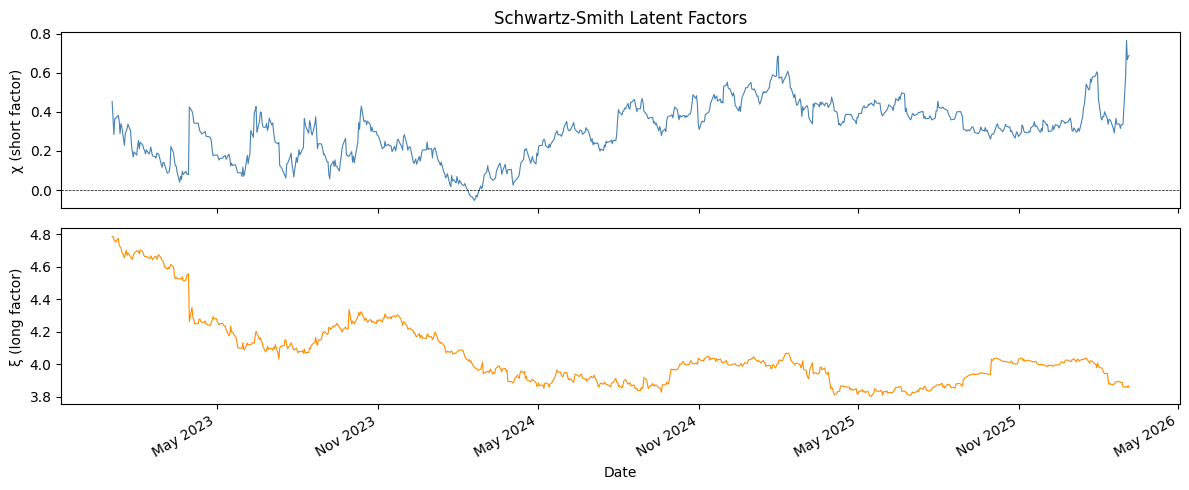

Forward curve model vs market (most recent date):
 tenor_yr  market_F  model_F  error_pct
     0.08    101.71    95.31       6.50
     0.17     99.60    95.48       4.22
     0.25     96.14    95.06       1.13
     0.33     95.26    94.20       1.11
     0.42     95.44    93.05       2.54
     0.50     96.32    91.69       4.93
     0.58     93.89    90.22       3.99
     0.67     94.85    88.68       6.72


In [5]:
# Plot estimated latent factors (from Kalman smoother approximation)
from src.processes.schwartz_smith import _forward_coefficients

A, B = _forward_coefficients(ss_params.kappa, ss_params.mu_xi,
                              ss_params.sigma_chi, ss_params.sigma_xi,
                              ss_params.rho, taus)
xi_hat  = log_fwd_panel[:, -1] - A[-1]
chi_hat = log_fwd_panel[:,  0] - A[0] - xi_hat

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
dates = panel.index
axes[0].plot(dates, chi_hat, lw=0.8, color='steelblue')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set(ylabel='χ (short factor)', title='Schwartz-Smith Latent Factors')
axes[1].plot(dates, xi_hat, lw=0.8, color='darkorange')
axes[1].set(ylabel='ξ (long factor)', xlabel='Date')
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

# Term structure fit at most recent date
print('Forward curve model vs market (most recent date):')
log_fwd_fit = A + B @ np.array([chi_hat[-1], xi_hat[-1]])
print(pd.DataFrame({
    'tenor_yr':  taus[:8].round(2),
    'market_F':  np.exp(log_fwd_panel[-1, :8]).round(2),
    'model_F':   np.exp(log_fwd_fit[:8]).round(2),
    'error_pct': ((log_fwd_panel[-1, :8] - log_fwd_fit[:8]) * 100).round(2),
}).to_string(index=False))

## Step 2 — PCA Hourly Shape Decomposition

Decompose the within-day half-hourly shape into 3 orthogonal factors.

- **PC1 (level)**: uniform shift up/down — driven by fuel costs, day-type
- **PC2 (slope)**: morning/evening asymmetry — driven by solar, industrial load
- **PC3 (curvature)**: peak/off-peak spread — driven by intraday demand swing

Each factor follows a mean-reverting OU process calibrated by AR(1) OLS.

In [6]:
# Negative prices floored at £1/MWh for log transform
n_neg = (df_da['price_gbp_mwh'] < 0).sum()
n_low = (df_da['price_gbp_mwh'] < 1).sum()
print(f'Negative price observations: {n_neg}  (floored to £1 for log-shape PCA)')
print(f'Observations below £1/MWh:   {n_low}')

print('\nCalibrating PCA shape decomposition...')
pca_params = calibrate_pca(df_da, n_factors=3, dt=1.0)
pca_params.to_json(PROC_DIR / 'pca_params.json')

evr = pca_params.explained_variance_ratio
print(f'\nVariance explained:')
for k in range(3):
    print(f'  PC{k+1}: {evr[k]*100:.1f}%')
print(f'  Total: {sum(evr)*100:.1f}%')

print(f'\nOU parameters:')
for k in range(3):
    hl = np.log(2) / max(pca_params.alpha[k], 0.01)
    print(f'  PC{k+1}: alpha={pca_params.alpha[k]:.3f}/day  sigma={pca_params.sigma_lambda[k]:.4f}  half-life={hl:.1f} days')

print(f'\nSaved to: {PROC_DIR}/pca_params.json')

Negative price observations: 1043  (floored to £1 for log-shape PCA)
Observations below £1/MWh:   37074

Calibrating PCA shape decomposition...

Variance explained:
  PC1: 42.6%
  PC2: 25.7%
  PC3: 8.7%
  Total: 76.9%

OU parameters:
  PC1: alpha=0.888/day  sigma=4.3607  half-life=0.8 days
  PC2: alpha=1.755/day  sigma=4.7611  half-life=0.4 days
  PC3: alpha=2.286/day  sigma=3.1701  half-life=0.3 days

Saved to: g:\My Drive\Research\bess_project\data\processed/pca_params.json


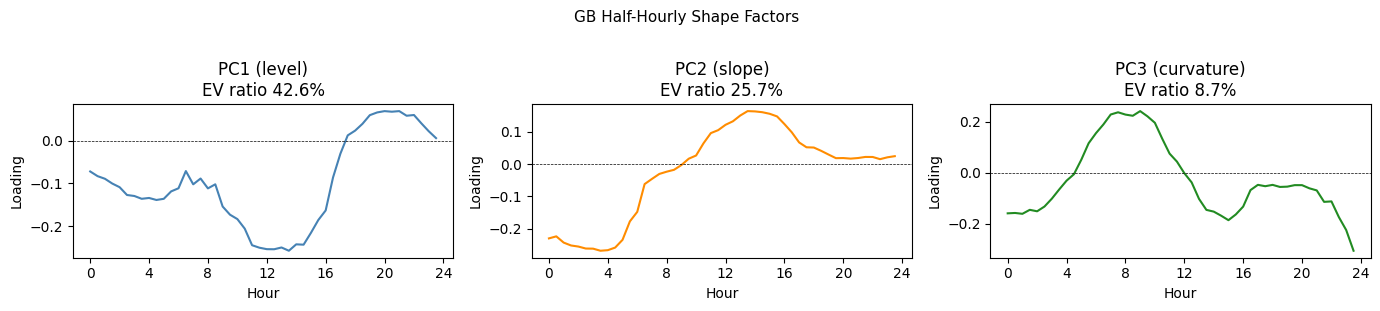

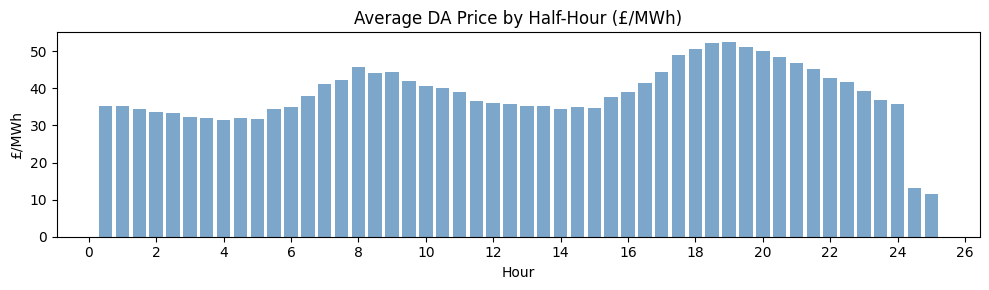

In [7]:
# Plot shape eigenvectors
phi = np.array(pca_params.loadings)
hours = np.arange(48) / 2

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
colors = ['steelblue', 'darkorange', 'forestgreen']
labels = ['PC1 (level)', 'PC2 (slope)', 'PC3 (curvature)']

for k, (ax, col, lab) in enumerate(zip(axes, colors, labels)):
    ax.plot(hours, phi[k], color=col, lw=1.5)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set(title=f'{lab}\nEV ratio {evr[k]*100:.1f}%', xlabel='Hour', ylabel='Loading')
    ax.xaxis.set_major_locator(plt.MultipleLocator(4))

plt.suptitle('GB Half-Hourly Shape Factors', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

avg_shape = df_da.groupby('settlement_period')['price_gbp_mwh'].mean()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(avg_shape.index / 2, avg_shape.values, width=0.4, color='steelblue', alpha=0.7)
ax.set(title='Average DA Price by Half-Hour (£/MWh)', xlabel='Hour', ylabel='£/MWh')
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.tight_layout(); plt.show()

## Step 3 — Imbalance Basis OU + Jump Calibration

Calibrate the arithmetic OU + compound Poisson model to the DA–SP basis.

**Key check:** GB had negative prices in April 2024 (53 hours).
The model uses arithmetic (not log-normal) OU to accommodate this.

Parameters:
- `theta` — mean-reversion speed: how fast basis snaps back
- `sigma` — diffusion volatility
- `lambda_J` — jump arrival rate (per half-hour)  
- `scale_pos/neg` — exponential scale for up/down jumps
- `p_pos` — proportion of jumps that are positive (system short)

In [8]:
print('Calibrating imbalance basis (OU + jump)...')
imb_params = imb_calibrate(df_da, df_sp, dt=1.0, threshold_sigma=2.5)
imb_params.to_json(PROC_DIR / 'imbalance_params.json')

print(f'\nImbalance basis parameters:')
print(f'  mu_delta    = {imb_params.mu_delta:.2f}  £/MWh (long-run mean)')
print(f'  theta       = {imb_params.theta_delta:.4f}/HH  (mean reversion per half-hour)')
print(f'  sigma       = {imb_params.sigma_delta:.4f}  £/MWh·(HH)^0.5')
print(f'  lambda_J    = {imb_params.lambda_jump:.4f}/HH  ({imb_params.lambda_jump*48*365:.0f} jumps/yr expected)')
print(f'  scale_pos   = {imb_params.jump_scale_pos:.2f}  £/MWh (system-short jump size)')
print(f'  scale_neg   = {imb_params.jump_scale_neg:.2f}  £/MWh (system-long jump size)')
print(f'  p_pos       = {imb_params.p_pos:.3f}  (fraction of upward jumps)')
print(f'  n_obs       = {imb_params.n_obs:,}')
print(f'  log-lik     = {imb_params.log_likelihood:.1f}')
print(f'\nSaved to: {PROC_DIR}/imbalance_params.json')

hl_hh = np.log(2) / imb_params.theta_delta if imb_params.theta_delta > 0 else np.nan
print(f'\nImbalance basis half-life: {hl_hh:.1f} half-hours = {hl_hh/2:.1f} hours')

Calibrating imbalance basis (OU + jump)...

Imbalance basis parameters:
  mu_delta    = 39.48  £/MWh (long-run mean)
  theta       = 6.9078/HH  (mean reversion per half-hour)
  sigma       = 46.9618  £/MWh·(HH)^0.5
  lambda_J    = 0.0604/HH  (1058 jumps/yr expected)
  scale_pos   = 152.48  £/MWh (system-short jump size)
  scale_neg   = 172.08  £/MWh (system-long jump size)
  p_pos       = 0.993  (fraction of upward jumps)
  n_obs       = 72,258
  log-lik     = -440220.7

Saved to: g:\My Drive\Research\bess_project\data\processed/imbalance_params.json

Imbalance basis half-life: 0.1 half-hours = 0.1 hours


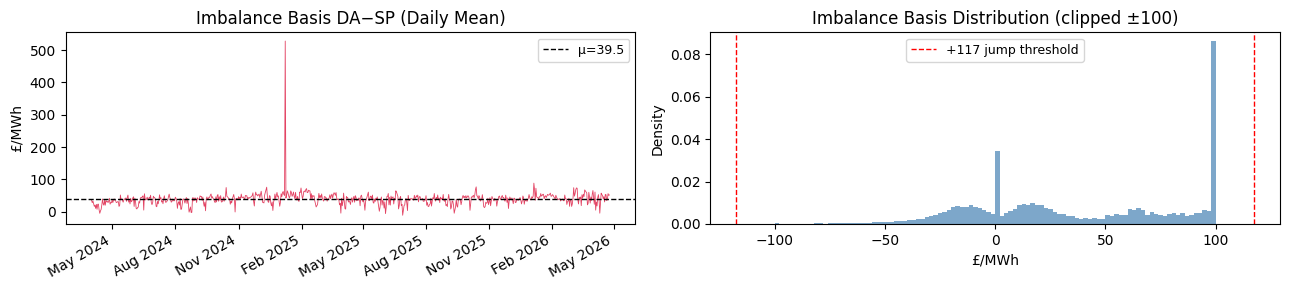

Observations above jump threshold: 7.7% (5555 of 72,258)


In [9]:
# Plot imbalance basis time series and histogram
merged = df_da[['settlement_date','settlement_period','price_gbp_mwh']].merge(
    df_sp[['settlement_date','settlement_period','system_price']],
    on=['settlement_date','settlement_period'], how='inner')
merged['basis'] = merged['system_price'] - merged['price_gbp_mwh']
daily_basis = merged.groupby('settlement_date')['basis'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(daily_basis.index, daily_basis.values, lw=0.6, color='crimson', alpha=0.8)
axes[0].axhline(imb_params.mu_delta, color='k', lw=1, ls='--', label=f'μ={imb_params.mu_delta:.1f}')
axes[0].set(title='Imbalance Basis DA−SP (Daily Mean)', ylabel='£/MWh')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

basis_all = merged['basis'].dropna()
threshold = 2.5 * imb_params.sigma_delta
axes[1].hist(basis_all.clip(-100, 100), bins=100, color='steelblue', alpha=0.7, density=True)
axes[1].axvline( threshold, color='red', lw=1, ls='--', label=f'+{threshold:.0f} jump threshold')
axes[1].axvline(-threshold, color='red', lw=1, ls='--')
axes[1].set(title='Imbalance Basis Distribution (clipped ±100)', xlabel='£/MWh', ylabel='Density')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

jump_frac = (basis_all.abs() > threshold).mean()
print(f'Observations above jump threshold: {jump_frac*100:.1f}% ({(basis_all.abs()>threshold).sum()} of {len(basis_all):,})')

## Step 4 — Ancillary AR(1) + Saturation Curve

Calibrate the AR(1) within-EFA-block persistence and the fleet saturation
exponent γ for each ancillary product.

> **If NESO data is empty (Phase 1 Step 3 failed):** Parameters default to
> calibration priors. Replace `data/raw/neso_eac_clearing.parquet` with
> manually downloaded CSVs converted to parquet, then re-run this cell.
>
> γ = 2.1 is calibrated to the DCL price collapse from £17/MW/h (2021)
> to £1–5/MW/h (2024) as GB BESS fleet grew from ~1 GW to ~6+ GW.

In [10]:
n_days_history = (df_da['settlement_date'].max() - df_da['settlement_date'].min()).days + 1
fleet_history = np.linspace(3500, 6500, n_days_history)

print('Calibrating ancillary service processes...')
if not df_anc.empty:
    print(f'  Products in data: {sorted(df_anc["product"].unique())}')
    print(f'  Date range: {df_anc["date"].min()} to {df_anc["date"].max()}')
else:
    print('  [WARN] No NESO ancillary data — using calibration priors')

anc_params = anc_calibrate(df_anc, fleet_mw_history=fleet_history)
anc_params.to_json(PROC_DIR / 'ancillary_params.json')

print(f'\nAncillary parameters:')
print(f'  gamma (saturation exponent) = {anc_params.gamma:.3f}')
print(f'  fleet_mw (current)          = {anc_params.fleet_mw:.0f} MW')
print(f'\nPer-product AR(1) parameters:')
print(f"{'Product':<12} {'phi':>6} {'sigma':>8} {'mu (£/MW/h)':>12} {'n_obs':>8}")
for name, pp in anc_params.products.items():
    print(f'{name:<12} {pp.phi:>6.3f} {pp.sigma:>8.3f} {pp.mu:>12.3f} {pp.n_obs:>8,}')
print(f'\nSaved to: {PROC_DIR}/ancillary_params.json')

Calibrating ancillary service processes...
  Products in data: ['BR', 'DC', 'DM', 'DR', 'QR']
  Date range: 2026-03-31 00:00:00 to 2026-04-25 00:00:00

Ancillary parameters:
  gamma (saturation exponent) = 2.100
  fleet_mw (current)          = 6500 MW

Per-product AR(1) parameters:
Product         phi    sigma  mu (£/MW/h)    n_obs
DC_Low        0.850    1.500        5.100        0
DC_High       0.850    1.500        5.100        0
DM_Low        0.850    1.500        6.000        0
DM_High       0.850    1.500        6.000        0
DR_Low        0.850    1.500        6.000        0
DR_High       0.850    1.500        6.000        0
QR_Pos        0.850    1.500        3.600        0
QR_Neg        0.850    1.500        2.400        0

Saved to: g:\My Drive\Research\bess_project\data\processed/ancillary_params.json


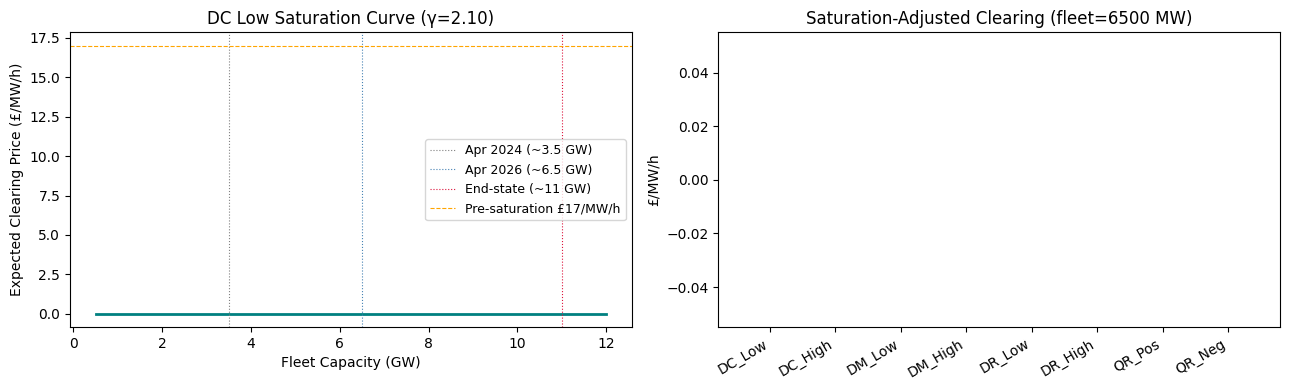

In [11]:
from src.processes.ancillary import saturation_price, SERVICE_VOLUME_MW, PEAK_PRICE

fleet_range = np.linspace(500, 12000, 200)
dc_sat = [saturation_price(q, SERVICE_VOLUME_MW['DC_Low'], PEAK_PRICE['DC_Low'], anc_params.gamma)
          for q in fleet_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(fleet_range/1000, dc_sat, color='teal', lw=2)
axes[0].axvline(3.5, color='gray',     lw=0.8, ls=':', label='Apr 2024 (~3.5 GW)')
axes[0].axvline(6.5, color='steelblue',lw=0.8, ls=':', label='Apr 2026 (~6.5 GW)')
axes[0].axvline(11,  color='crimson',  lw=0.8, ls=':', label='End-state (~11 GW)')
axes[0].axhline(17,  color='orange',   lw=0.8, ls='--',label='Pre-saturation £17/MW/h')
axes[0].set(title=f'DC Low Saturation Curve (γ={anc_params.gamma:.2f})',
            xlabel='Fleet Capacity (GW)', ylabel='Expected Clearing Price (£/MW/h)')
axes[0].legend(fontsize=9)

products_plot = ['DC_Low', 'DC_High', 'DM_Low', 'DM_High', 'DR_Low', 'DR_High', 'QR_Pos', 'QR_Neg']
current_clearing = [saturation_price(anc_params.fleet_mw,
                                     SERVICE_VOLUME_MW[p], PEAK_PRICE[p], anc_params.gamma)
                    for p in products_plot]
axes[1].bar(range(len(products_plot)), current_clearing, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(products_plot)))
axes[1].set_xticklabels(products_plot, rotation=30, ha='right')
axes[1].set(title=f'Saturation-Adjusted Clearing (fleet={anc_params.fleet_mw:.0f} MW)', ylabel='£/MW/h')
plt.tight_layout(); plt.show()

## Validation Summary

All four processes should be calibrated with plausible parameters.

| Parameter | Expected range | Flag |
|-----------|---------------|------|
| SS kappa | 0.5–10 (half-life 1–17 months) | Warn outside |
| SS sigma_chi | 0.15–0.80 | Warn outside |
| SS sigma_xi | 0.05–0.40 | Warn outside |
| PCA PC1+PC2+PC3 variance | > 70% | Warn if < 70% |
| Imbalance theta | 1–50/HH | Warn outside |
| Imbalance lambda_J | 0.01–0.30/HH | Warn outside |
| Ancillary gamma | 1.0–5.0 | Warn outside |

In [12]:
print('=' * 60)
print('PHASE 2 VALIDATION SUMMARY')
print('=' * 60)

all_ok = True

def check(name, val, lo, hi, unit=''):
    global all_ok
    ok = lo <= val <= hi
    sym = 'OK  ' if ok else 'WARN'
    if not ok: all_ok = False
    print(f'  [{sym}]  {name}: {val:.4f} {unit}  (expected {lo}–{hi})')

print('\nSchwartz-Smith:')
check('kappa',      ss_params.kappa,     0.5, 10.0,  '1/yr')
check('sigma_chi',  ss_params.sigma_chi, 0.10, 0.90, '')
check('sigma_xi',   ss_params.sigma_xi,  0.02, 0.50, '')
check('|rho|',      abs(ss_params.rho),  0.0, 0.99,  '')

print('\nPCA shape:')
pca_total_ev = sum(pca_params.explained_variance_ratio)
ok_pca = pca_total_ev >= 0.65
sym = 'OK  ' if ok_pca else 'WARN'
if not ok_pca: all_ok = False
print(f'  [{sym}]  PC1+PC2+PC3 variance: {pca_total_ev*100:.1f}%  (expected > 65%)')
for k in range(3):
    hl = np.log(2) / max(pca_params.alpha[k], 0.001)
    print(f'  [INFO]  PC{k+1}: alpha={pca_params.alpha[k]:.3f}/day  half-life={hl:.1f} days')

print('\nImbalance basis:')
check('theta_delta', imb_params.theta_delta, 0.5, 100.0, '/HH')
check('sigma_delta', imb_params.sigma_delta, 0.5, 50.0, '£/MWh')
check('lambda_jump', imb_params.lambda_jump, 0.001, 0.50, '/HH')

print('\nAncillary saturation:')
check('gamma', anc_params.gamma, 1.0, 6.0, '')

print()
print('RESULT:', 'All parameters plausible — ready for Phase 3 simulation'
      if all_ok else 'Some parameters outside expected range — see notes above')
print('Next: notebooks/03_simulation.ipynb')
print()

for fname in ['ss_params.json', 'pca_params.json', 'imbalance_params.json', 'ancillary_params.json']:
    p = PROC_DIR / fname
    sym = 'OK  ' if p.exists() else 'FAIL'
    print(f'  [{sym}]  {p.name}')

PHASE 2 VALIDATION SUMMARY

Schwartz-Smith:
  [OK  ]  kappa: 1.1912 1/yr  (expected 0.5–10.0)
  [WARN]  sigma_chi: 1.4745   (expected 0.1–0.9)
  [OK  ]  sigma_xi: 0.1467   (expected 0.02–0.5)
  [OK  ]  |rho|: 0.2174   (expected 0.0–0.99)

PCA shape:
  [OK  ]  PC1+PC2+PC3 variance: 76.9%  (expected > 65%)
  [INFO]  PC1: alpha=0.888/day  half-life=0.8 days
  [INFO]  PC2: alpha=1.755/day  half-life=0.4 days
  [INFO]  PC3: alpha=2.286/day  half-life=0.3 days

Imbalance basis:
  [OK  ]  theta_delta: 6.9078 /HH  (expected 0.5–100.0)
  [OK  ]  sigma_delta: 46.9618 £/MWh  (expected 0.5–50.0)
  [OK  ]  lambda_jump: 0.0604 /HH  (expected 0.001–0.5)

Ancillary saturation:
  [OK  ]  gamma: 2.1000   (expected 1.0–6.0)

RESULT: Some parameters outside expected range — see notes above
Next: notebooks/03_simulation.ipynb

  [OK  ]  ss_params.json
  [OK  ]  pca_params.json
  [OK  ]  imbalance_params.json
  [OK  ]  ancillary_params.json
